# Figure2(Stackedbar) for bertopic

In [16]:
visualization_target = input("INPUT 'visualization_target RUN_ID'(e.g., run_id_10): ")
model_in_run = input("INPUT 'model_in_run'(e.g., bert_based, lda, tag): ")

In [17]:
import os 
import numpy as np
import pandas as pd
from datetime import datetime
import pprint

from setting_for_sda.color_setting import Color_Setting
from setting_for_sda.date_setting import Date_Setting
from setting_for_sda.path_setting import path_list

import lib.stats.stats as st
from lib.utils.statistics import *
from matplotlib import pyplot as plt

import matplotlib as mpl
import lib.visualization.plot_generator as PlotGen
import lib.visualization.font_setting as font_setting
from lib.visualization.distribution_collector import (proportion_calc_for_topic, 
                                                      collect_top_bottom_topic)
mpl.rcParams['font.family'] = font_setting.init_font()

Helvetica /home/mghan/.fonts/Helvetica/Helvetica Bold Oblique.ttf
Registered font name: Helvetica


In [18]:
color_list = Color_Setting.color_list
alpha_list = [1, 1, 0.7]

In [19]:
viz_dir = f'{path_list["data_root_dir"]}/result/{model_in_run}/{visualization_target}'
data_dir = f"{viz_dir}/data"
option_dict = load_json(f"{viz_dir}/option.json")

output_dir = './fig/'
date_range = 'Weekly'

std_date = Date_Setting[option_dict['year_range']]['std_date']

pprint.pprint(option_dict)

{'data_dir': '/mnt/hdd/mghan/so_data_availability/data/public_for_260105/questions/python/2021to2025',
 'model': 'BERTopic',
 'model_option': {'clustering': {'n_clusters': 50, 'name': 'kmeans'},
                  'embedding_model': None,
                  'model_type': 'text',
                  'nr_topics': None,
                  'vectorizer': 'CountVectorizer'},
 'run_id': '14',
 'save_dir': '/mnt/hdd/mghan/so_data_availability/result/bert_based/run_id_14',
 'selected_tags': None,
 'snapshot': 'public_for_260105',
 'visualization': {'n': 10},
 'year_range': '2021to2025'}


In [20]:
df = load_df(data_dir, ['id' , 'creationdate' , 'title', 'tags', 'body', 'Topic'])

In [21]:
df['creationdate'] = pd.to_datetime(df['creationdate'], format="mixed").dt.normalize()
df['rel_week'] = ((df['creationdate'] - std_date).dt.days // 7)

In [22]:
print(df['creationdate'].min())
print(df['creationdate'].max())

2021-12-01 00:00:00
2025-11-25 00:00:00


In [23]:
df[df['rel_week'] == 52]

,id,creationdate,title,tags,body,Document,Topic,rel_week
189640,77599070,2023-12-04,ElementTree : extract attribute value using fi...,<python><xml><elementtree>,<p>Wanted to extract the value of name attribu...,Wanted to extract the value of name attribute ...,8,52
189660,77581145,2023-11-30,Joining 2 separate excel based 1 condition wit...,<python><pandas><dataframe><numpy><jupyter-not...,<p>I have these two frames</p>\n<p>df1</p>\n<d...,I have these two frames\ndf1\n\n\n\n\nbirthdat...,30,52
189661,77582315,2023-11-30,rankN type equivalent for mypy in python,<python><haskell><types><mypy>,<p>In Haskell we can use rankN types like so:<...,In Haskell we can use rankN types like so:\nra...,15,52
189662,77582815,2023-12-01,How to randomly map a proportion of data value...,<python><random-seed><numpy-random>,<p>I have a dataset below which shows if a cus...,I have a dataset below which shows if a custom...,16,52
189663,77590982,2023-12-02,How to specify a Windows USB com port instead ...,<python><windows><serial-port><pyserial>,<p>I am trying to run the python <strong>ramse...,I am trying to run the python ramses rf-master...,26,52
...,...,...,...,...,...,...,...,...
325045,77594571,2023-12-03,Convert LineString to Polygon using Python,<python><pandas><geojson><geopandas><shapely>,<p>I am trying to convert geometry from type: ...,I am trying to convert geometry from type: Lin...,35,52
325046,77595758,2023-12-03,Efficient copying of an ensemble in JAX,<python><jax>,<p>I have an ensemble of models and want to as...,I have an ensemble of models and want to assig...,11,52
325047,77596108,2023-12-03,don't know whats causing this error in my inte...,<python><interpreter>,<p>making a language interpreter in python but...,making a language interpreter in python but ra...,4,52
325048,77596393,2023-12-03,Adding a string to an array and giving it a nu...,<python><arrays><sorting>,<p>I want to add text from an input into an ar...,I want to add text from an input into an array...,6,52


In [24]:
prop_df = proportion_calc_for_topic(df, 'rel_week', 'Topic')

In [25]:
top10list, mid30list, bot10list = collect_top_bottom_topic(prop_df, 'rel_week', 'Topic', 'proportion')

list_10 = {'Top 20% Topics' : top10list, 
               'Bottom 20% Topics' : bot10list}


df_dict = {'Top 20% Topics'       : prop_df[prop_df['Topic'].isin(top10list)],   
          'Bottom 20% Topics'     : prop_df[prop_df['Topic'].isin(bot10list)]}

    


In [26]:
# calculate entropy and gini by weekly manner
df_coef = {'Entropy' : prop_df.groupby(['rel_week'])['proportion'].apply(lambda x : calculate_entropy(x)).to_frame(name='Entropy').reset_index(),
           'Gini'    : prop_df.groupby(['rel_week'])['proportion'].apply(lambda x : calculate_gini(x)).to_frame(name = 'Gini').reset_index()}

In [27]:
plot_gen = PlotGen.PlotGen()

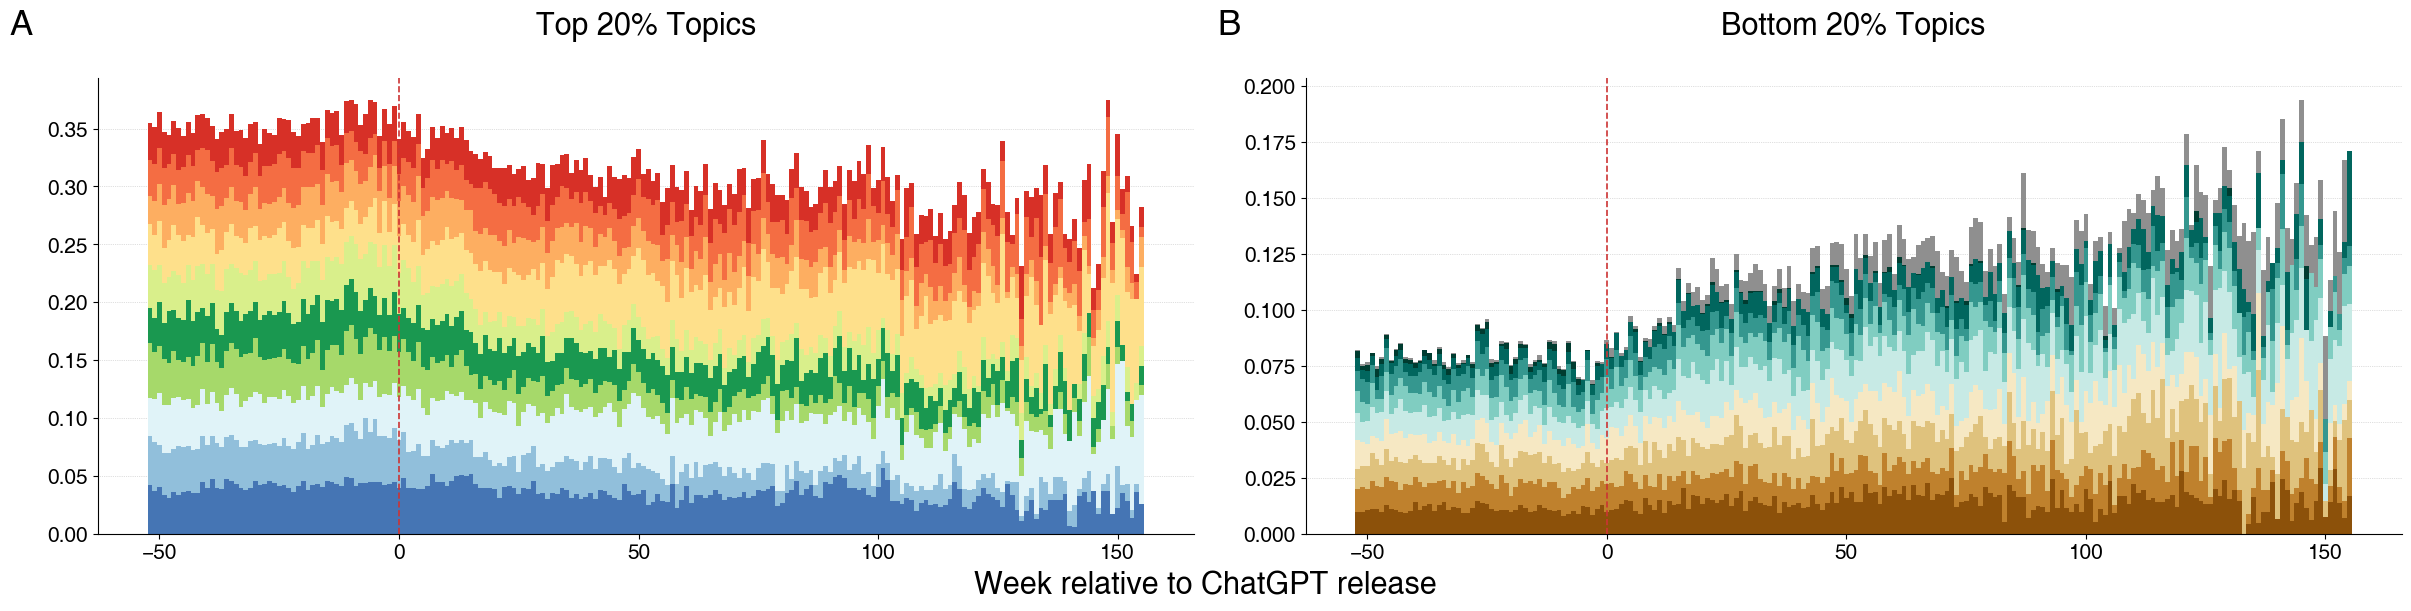

In [28]:
fig, axs = plt.subplots(1, 2, figsize=(24, 6), constrained_layout=True)

panel_labels = ['A', 'B', 'C', 'D']
### stacked topic plots
for i, (title, proportion) in enumerate(df_dict.items()):

    plot_gen.draw_topic_stack(
        axs[i],
        title,
        panel_labels[i], 
        proportion,
        list_10[title],
        color_list[i],
        alpha_list[i]
    )


fig.supxlabel("Week relative to ChatGPT release", fontsize=22)

plt.savefig(f"{output_dir}{option_dict['model']}_{option_dict['year_range']}", dpi=300, bbox_inches='tight')
plt.show()